In [124]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d

I am going to put code here as a reminder to Qutip notation: see Overleaf for more details.

In [125]:
up = basis(2, 0) # up state
print(up)
print(sigmam() * up) # if in the excited state, should end up in the ground state
print(sigmap() * up) # if in the excited state, we have raised the qubit state out of the truncated TLS Hilbert space, yielding [0; 0] 

down = basis(2, 1) # down state
print(down)
print(sigmam() * down) # if in the ground state, we have lowered the qubit state out of the truncated TLS Hilbert space, yielding [0; 0] 
print(sigmap() * down) # if in the ground state, should end up in the excited state

print(expect(sigmaz(), up)) # +1 for up spin
print(expect(sigmaz(), down)) # -1 for down spin

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]]
Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]
1.0
-1.0


# Two-Level System

I am considering interaction between an atom and 1D light field as outlined in RbQ Method Overleaf (freespace2level pdf). A single coherent beam interacting with a single atom has the Hamiltonian:

$$\hat{H} = g \hat{\textbf{a}}(t)\hat{\sigma}_+ + g^* \hat{\textbf{a}}^\dagger(t)\hat{\sigma}_-$$

- $g$ is the coupling betwen the light and atom.
- $\hat{\textbf{a}}(t)$ is a bath operator which is different at each point in time (?). This is defined as $\hat{\textbf{a}}(t)= \hat{a}_0(t) + \alpha(t) $, where $\hat{a}_0(t)$ is the vacuum annihilation operator. 

For simplicity, I am considering the case where the driving field (photon) is coherent ($\alpha$ and $g$ are both real) interacts with a two-level system (TLS). We also ignore the vacuum field, which is under the assumption that the $\alpha$ is much larger than vacuum. Eventually, we will have to account for vacuum since our $\alpha$ is small. This leads to:

$$\hat{H} = -g(t)\alpha(t) \hat{\sigma}_x$$

### 1). Input wavepacket $\alpha(t)$
First, we will assume the incoming wavepacket $\alpha(t)$ has a Gaussian profile. The average occupation number $N$ (number of photons) in the pulse $\alpha$ is given by $$N=\int_{-\infty}^\infty{|\alpha(t)|^2 dt}$$ 

So, the normalized expression for a pulse with $N=1$ is:

$$\alpha(t) = \sqrt{\frac{1}{\sigma\sqrt{\pi}}} e^{-(x-\mu)^2/2\sigma^2}$$

where $\mu$, $\sigma$ are the mean and standard deviation of the Gaussian, respectively. This expression describes the average energy of a single photon. A temporal mode is a BASIS with energy equal to 1. 

I am currently assuming that the coupling strength $g$ is constant. 

In [126]:
### INPUT PARAMETERS
T = 10 # total time (input pulse "duration")
N = 5000 # number of time steps
time = np.linspace(0, T, N)

mu, sigma = 5/2, 5/10
a = 0.1*np.sqrt(1/(sigma*np.sqrt(np.pi))) # small amplitude

def alpha_in(t):
    return a * np.exp(-((t - mu)**2) / (2 * sigma**2)) # Gaussian input
alpha = alpha_in(time)
print("Area of alpha:", integrate.simps(alpha**2, time))

Area of alpha: 0.00999999999999231


### 2). Define optimal coupling g(t)

We want to find the optimal shaped write pulse $g(t)$ (aka the ideal coupling) that maximizes excited state probability (the amount of excited state absorbed from the coherent state) with decay. We don't want to change $\alpha(t)$ since we want to accommodate an arbitrary temporal mode. From Eq. 56 in the freespace2level pdf, we have 

$$
g^*(t) = \frac{k_{||}(t)}{\sqrt{\int_{-\infty}^t |k_{||}(t)|^2dt}}
$$

where $k_{||}(t)$ is the normalized template that overlaps with the incoming signal. This is similar to Gorshkov but without the phase term. We will set this to be the same shape as $\alpha_{in}$ (Gaussian) since that would be a perfect overlap. 

- What does normalized mean? I interpret this as $ \int_{-\infty}^\infty{k(t)dt} = 1$, should it be $ \int_{-\infty}^\infty{k(t)^2dt} = 1$?
- How do I test the rejection? If I make a completely orthogonal template to $\alpha$, what does that look like?

Area of template k(t): 0.11059960846405642


(0.0, 14.0)

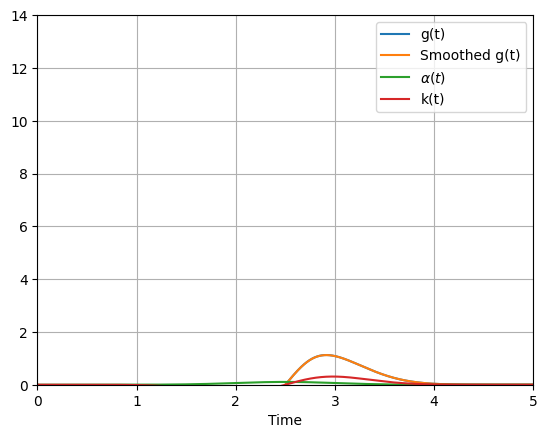

In [127]:
### TEMPLATE FUNCTION (k(t) = template at time t)
def k(t):
    a = np.sqrt(1/(sigma*np.sqrt(np.pi))) # for normalized area
    #return a * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian
    return a * np.exp(-((t-mu)**2) / (2*sigma**2)) * np.sin(t-mu) # for orthogonal template (to input)

### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
def g(t):
    integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
    return k(t) / np.sqrt(integral_value) if integral_value > 0 else 0

g_vals, k_vals = [], []
for t in time: 
    g_vals.append(g(t)) 
    k_vals.append(k(t))

print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))

g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
def g_smoothed(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

plt.plot(time, g_vals, label='g(t)')
plt.plot(time, [g_smoothed(t) for t in time], label='Smoothed g(t)')  # Plot smoothed g(t)
plt.plot(time, [alpha_in(t) for t in time], label=r'$\alpha(t)$')
plt.plot(time, k_vals, label='k(t)')
plt.legend(); plt.grid(); plt.xlabel('Time')
plt.xlim([0, 5]); plt.ylim([0, 14])

Here, we can see the coupling shape needed to maximally spin up kind of matches the math in the Gorshkov paper. This shape intuitively makes sense because you have a large increase in the coupling at the beginning to "record" as much of the incoming pulse as possible. 

### 3). Define Hamiltonian and solve Lindblad Master Equation
Recall we have defined the Hamiltonian of our system:

$$\hat{H} = -g(t)\alpha(t) \hat{\sigma}_x$$

We will solve this time-dependent Hamiltonian (solved in Qutip found in https://qutip.org/docs/4.7/guide/dynamics/dynamics-time.html) and determine the expectation value of the atom's state, to see if the atom has "spun up" as expected. We include collapse operators because we must account for the atom spontaneously decaying (e to g). For a given bath mode, the Lindblad collapse operators are given by $$L= -g^*\hat{\sigma}_- $$ where $g$ is a function of time and $\hat{\sigma}_-$ is the lowering operator on the TLS ($\ket{g}\bra{e}$).

In [128]:
### HAMILTONIAN
H0 = Qobj([[0, 0], [0, 0]]) # time-independent part of Hamiltonian
H1 = Qobj([[0, 1], [1, 0]])  
def H1_coeff(t, args): 
    return g_smoothed(t) * alpha_in(t) 
H = [H0,[H1, H1_coeff]] # Final Hamiltonian

# DISSIPATION OPERATORES (collapse operators)
def col_coeff(t, args):  # coefficient function
    return -np.conjugate(g_smoothed(t))
c_op_list = [[sigmam(), col_coeff]]  # time-dependent collapse term

# H[1][1](t, None) = H1_coeff at time t

### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = basis(2, 1) # |g> in the sigma z basis = [1, 0]'
result = mesolve(H, psi0, time, c_op_list) 

### 4). Evaluate Spin Results
The spin value is defined as: $ S(t) = \langle \hat{\sigma}_- \rangle $ where $ \hat{\sigma}_- = | g \rangle \langle e |$. If we define an atom's state $\ket{\psi}= c_g\ket{g} + c_e\ket{e}$, this makes the expectation value $$\langle S \rangle = c_g^*c_e$$ 

We will use $S$ as a metric for how much of the incoming pulse is stored in the atom's excited state because we are considering weak signals, aka signals where the amplitude of the input pulse is small and therefore $c_g \sim 1$ at all times. We are trying to maximize the excited state probability $c_e$, which is equivalent in this limit to maximizing $S$.

Note that in the case outside of this limit, it is possible that even if the atom is excited/spun up all the way ($c_e=1$),  $S=0$ because $c_g = 0$.
- Is it okay that the expectation of S is entirely imaginary? Physical intuition?

In [129]:
prob_ground = [] # probability of finding state in |g>
prob_excited = [] # probability of finding state in |e>
S_expect = [] # expectation value of lowering operator
for i in range(0, len(result.states)):
    p_g, p_e = result.states[i][1][1], result.states[i][0][0]    
    prob_ground = np.append(prob_ground, p_g)
    prob_excited = np.append(prob_excited, p_e)
    S_expect = np.append(S_expect, expect(sigmam(), result.states[i]))

print('Final S: ', abs(S_expect[-1]))
print("Max excited state population:", max(prob_excited))
print("Final excited state population:", prob_excited[-1])

Final S:  6.378853536927526e-05
Max excited state population: (0.0033037057485747197+0j)
Final excited state population: (1.1316108186157827e-06+0j)


We can confirm the validity of our spin curve because from RbQ Method, we expect:

$$S^2 = \int_0^t {\alpha^2_{in}(t)dt}$$

0.31622776601677716


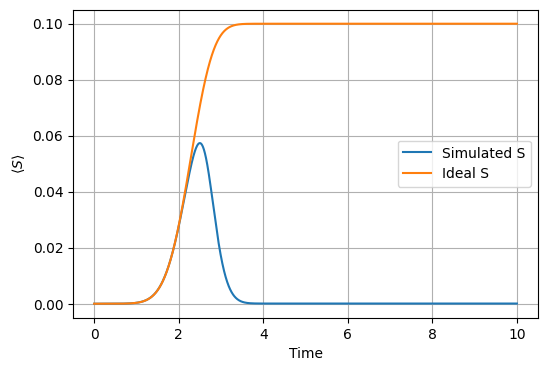

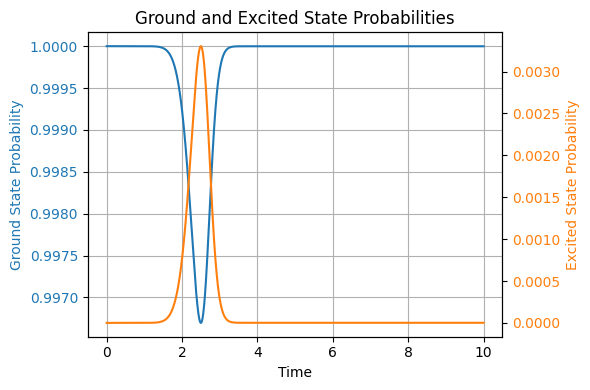

In [130]:
plt.figure(figsize=(6,4))
plt.plot(time, abs(S_expect), label='Simulated S')

S_ideal = []
for i in range(0, len(time)):
    if i == 0: S_ideal.append(0)
    else:      S_ideal.append(np.sqrt(integrate.simps(abs(alpha[0:i])**2, time[0:i])))
plt.plot(time, np.abs(S_ideal), label='Ideal S')
#plt.xlim([0, 20])
print(np.sqrt(S_ideal[-1]))
plt.ylabel(r'$\langle S \rangle$'); plt.xlabel('Time'); plt.grid(); plt.legend()

fig, ax1 = plt.subplots(figsize=(6, 4))
color = 'tab:blue'
ax1.set_xlabel('Time')
ax1.set_ylabel('Ground State Probability', color=color)
ax1.plot(time, prob_ground, label='Ground State', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid()


ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Excited State Probability', color=color)
ax2.plot(time, prob_excited, label='Excited State', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Ground and Excited State Probabilities')
plt.tight_layout()
#plt.xlim([0, 20])
plt.show()

1/f squared, amplitude relation (does not go straight to zero)

alpha - g S --> warps the output signal
the coherent state is the incoming signal

Questions:
- What is $\alpha(t)$? (how does the $\alpha$ look as a matrix ?? to sum with the vacuum annihilation operator)
- The incoming state is coherent so this simulation is not entirely accurate - but single photons can't be coherent states but isn't that what we're trying to detect using RbQ? I'm confused now lol, the template is not coherent?
- When we tensor these two, it seems like you're treating the two Hilbert spaces as independent. Is this the case?
- We are assuming this $\alpha(t)$ is coherent, but this is not accurate for a single photon because a coherent state is a sum of Fock states (so need more than 1 photon physically?)
- Can there be decay arising from the bath terms, not just spontaneous decay? like the photon may be deformed as it's travelling or something?
- incoming pulse is always gaussian? what is gaussian here
- What is the metric for how "good" our system is behaving?

We will observe in the three-level system that efficiencies don't work well because of the AC stark shift - to correct this, detune frequencies of input light which corrects stark shift during the simulation (phase factor from h). We will pick up phase in the template if we don't account for stark shift (diff dressed state energy shift between the 2 ground states).